# Existing Models


Loading normal images...
Path C:\Users\T2410216\Desktop\Model1\Datasets\Augmented\Brain_AD\Normal not found or no images found. Creating dummy data.
Loading abnormal images...
Path C:\Users\T2410216\Desktop\Model1\Datasets\Augmented\Brain_AD\Abnormal not found or no images found. Creating dummy data.
Loaded 100 normal images and 100 abnormal images


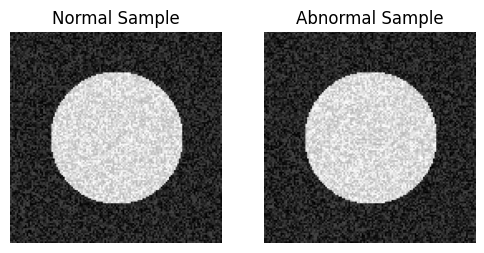


Training Fully Connected Autoencoder...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 847ms/step - loss: 0.0872 - val_loss: 0.0166
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - loss: 0.0203 - val_loss: 0.0108
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 387ms/step - loss: 0.0083 - val_loss: 0.0068
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - loss: 0.0059 - val_loss: 0.0053
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 384ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 425ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 10/100
2/5 ━━━━━━━━━━━━━━━━━━━━ 1s 367ms/step - loss: 0.0034

KeyboardInterrupt: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten, Lambda, Concatenate, Layer, BatchNormalization, LeakyReLU, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import os, glob, cv2
from PIL import Image
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split


normal_path = r"C:\Users\T2410216\Desktop\Model1\Datasets\Augmented\Brain_AD\Normal"
abnormal_path = r"C:\Users\T2410216\Desktop\Model1\Datasets\Augmented\Brain_AD\Abnormal"

IMG_SIZE = (128, 128)

def load_images(path, img_size=IMG_SIZE, normalization="[0, 1]", max_images=5000):
    images = []
    image_files = glob.glob(os.path.join(path, "*.png")) + glob.glob(os.path.join(path, "*.jpg"))

    if not os.path.exists(path) or not image_files:
        print(f"Path {path} not found or no images found. Creating dummy data.")
        if "normal" in path.lower():
            return create_dummy_normal_data(100, img_size)
        else:
            return create_dummy_abnormal_data(50, img_size)

    print(f"Found {len(image_files)} images in {path}")

    image_files = image_files[:max_images]

    for img_path in image_files:
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize(img_size)

            img_array = np.array(img).astype('float32')

            if normalization == "[0, 1]":
                img_array = img_array / 255.0
            elif normalization == "[-1, 1]":
                img_array = (img_array / 127.5) - 1.0

            images.append(img_array)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    return np.array(images)

def create_dummy_normal_data(n_samples=100, img_size=IMG_SIZE):
    normal_images = np.random.rand(n_samples, img_size[0], img_size[1]) * 0.2
    for i in range(n_samples):
        center = (img_size[0]//2, img_size[1]//2)
        for x in range(img_size[0]):
            for y in range(img_size[1]):
                dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
                if dist < 40:
                    normal_images[i, x, y] += 0.5
    return normal_images

def create_dummy_abnormal_data(n_samples=50, img_size=IMG_SIZE):
    abnormal_images = create_dummy_normal_data(n_samples, img_size)
    for i in range(n_samples):
        x_anom = np.random.randint(img_size[0]//4, 3*img_size[0]//4)
        y_anom = np.random.randint(img_size[1]//4, 3*img_size[1]//4)
        abnormal_images[i, x_anom-10:x_anom+10, y_anom-10:y_anom+10] = 1.0
    return abnormal_images

print("Loading normal images...")
normal_images = load_images(normal_path, img_size=IMG_SIZE)
print("Loading abnormal images...")
abnormal_images = load_images(abnormal_path, img_size=IMG_SIZE)

print(f"Loaded {len(normal_images)} normal images and {len(abnormal_images)} abnormal images")


normal_labels = np.zeros(len(normal_images))
abnormal_labels = np.ones(len(abnormal_images))

x_train_normal, x_test_normal = train_test_split(normal_images, test_size=0.2, random_state=42)

x_test = np.concatenate([x_test_normal, abnormal_images])
y_test = np.concatenate([np.zeros(len(x_test_normal)), np.ones(len(abnormal_images))])


plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title("Normal Sample")
plt.imshow(normal_images[0], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Abnormal Sample")
plt.imshow(abnormal_images[0], cmap='gray')
plt.axis('off')

plt.show()


img_height, img_width = IMG_SIZE
input_dim = img_height * img_width

x_train_fc = x_train_normal.reshape((len(x_train_normal), input_dim))
x_test_fc = x_test.reshape((len(x_test), input_dim))

x_train_cnn = x_train_normal.reshape((len(x_train_normal), img_height, img_width, 1))
x_test_cnn = x_test.reshape((len(x_test), img_height, img_width, 1))


n_conditions = 3
train_conditions = np.random.randint(0, n_conditions, size=len(x_train_normal))
test_conditions = np.random.randint(0, n_conditions, size=len(x_test))


train_conditions_onehot = to_categorical(train_conditions, n_conditions)
test_conditions_onehot = to_categorical(test_conditions, n_conditions)

# 1. Fully Connected Autoencoder
input_fc = Input(shape=(input_dim,))
encoded_fc = Dense(1024, activation='relu')(input_fc)
encoded_fc = Dense(512, activation='relu')(encoded_fc)
encoded_fc = Dense(256, activation='relu')(encoded_fc)


encoded_fc = Dense(128, activation='relu')(encoded_fc)


decoded_fc = Dense(256, activation='relu')(encoded_fc)
decoded_fc = Dense(512, activation='relu')(decoded_fc)
decoded_fc = Dense(1024, activation='relu')(decoded_fc)
decoded_fc = Dense(input_dim, activation='sigmoid')(decoded_fc)

autoencoder_fc = Model(input_fc, decoded_fc)
autoencoder_fc.compile(optimizer='adam', loss='mse')

# 2. Convolutional Autoencoder
input_cnn = Input(shape=(img_height, img_width, 1))


x = Conv2D(32, (3, 3), strides=2, padding='same')(input_cnn)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2D(64, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2D(128, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)


encoded_cnn = x


x = Conv2DTranspose(128, (3, 3), strides=2, padding='same')(encoded_cnn)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

decoded_cnn = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_cnn = Model(input_cnn, decoded_cnn)
autoencoder_cnn.compile(optimizer='adam', loss='mse')

# Custom VAE loss layer
class VAELossLayer(Layer):
    def __init__(self, beta=1.0, **kwargs):
        self.beta = beta
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs
        reconstruction_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(x, x_decoded)) * input_dim
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        total_loss = reconstruction_loss + self.beta * kl_loss
        self.add_loss(total_loss)
        return x_decoded

# 3. Variational Autoencoder
# sampling function
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Parameters
latent_dim = 128

# encoder
inputs_vae = Input(shape=(input_dim,))
x = Dense(1024, activation='relu')(inputs_vae)
x = Dense(512, activation='relu')(x)
z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)
z = Lambda(sampling)([z_mean, z_log_var])

# decoder
x = Dense(512, activation='relu')(z)
x = Dense(1024, activation='relu')(x)
outputs_vae = Dense(input_dim, activation='sigmoid')(x)

# custom loss layer
vae_output = VAELossLayer(beta=0.01)([inputs_vae, outputs_vae, z_mean, z_log_var])

# VAE model
vae = Model(inputs_vae, vae_output)
vae.compile(optimizer='adam')

# 4. Beta-VAE
# Parameters
latent_dim_beta = 128
beta_value = 10.0

# encoder
inputs_beta = Input(shape=(input_dim,))
x = Dense(1024, activation='relu')(inputs_beta)
x = Dense(512, activation='relu')(x)
z_mean_beta = Dense(latent_dim_beta)(x)
z_log_var_beta = Dense(latent_dim_beta)(x)
z_beta = Lambda(sampling)([z_mean_beta, z_log_var_beta])

# decoder
x = Dense(512, activation='relu')(z_beta)
x = Dense(1024, activation='relu')(x)
outputs_beta = Dense(input_dim, activation='sigmoid')(x)

beta_vae_output = VAELossLayer(beta=beta_value)([inputs_beta, outputs_beta, z_mean_beta, z_log_var_beta])

# Beta-VAE model
beta_vae = Model(inputs_beta, beta_vae_output)
beta_vae.compile(optimizer='adam')

# 5. Conditional VAE
# Custom CVAE loss layer
class CVAELossLayer(Layer):
    def __init__(self, beta=1.0, **kwargs):
        self.beta = beta
        super(CVAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs
        reconstruction_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(x, x_decoded)) * input_dim
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        total_loss = reconstruction_loss + self.beta * kl_loss
        self.add_loss(total_loss)
        return x_decoded

# Parameters
latent_dim_cvae = 128

# encoder with condition
inputs_cvae = Input(shape=(input_dim,))
condition_input = Input(shape=(n_conditions,))
x = Concatenate()([inputs_cvae, condition_input])
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
z_mean_cvae = Dense(latent_dim_cvae)(x)
z_log_var_cvae = Dense(latent_dim_cvae)(x)
z_cvae = Lambda(sampling)([z_mean_cvae, z_log_var_cvae])

# decoder with condition
z_cond = Concatenate()([z_cvae, condition_input])
x = Dense(512, activation='relu')(z_cond)
x = Dense(1024, activation='relu')(x)
outputs_cvae = Dense(input_dim, activation='sigmoid')(x)

# custom loss layer
cvae_output = CVAELossLayer()([inputs_cvae, outputs_cvae, z_mean_cvae, z_log_var_cvae])

# CVAE model
cvae = Model([inputs_cvae, condition_input], cvae_output)
cvae.compile(optimizer='adam')

# 6. VQ-VAE
# encoder
inputs_vq = Input(shape=(img_height, img_width, 1))

# Encoder
x = Conv2D(32, (3, 3), strides=2, padding='same')(inputs_vq)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2D(64, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2D(128, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

# Bottleneck
encoded_vq = Conv2D(64, (1, 1), padding='same')(x)
encoded_vq = BatchNormalization()(encoded_vq)
encoded_vq = LeakyReLU(0.2)(encoded_vq)

# Decoder
x = Conv2DTranspose(128, (3, 3), strides=2, padding='same')(encoded_vq)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.2)(x)

decoded_vq = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)


vqvae = Model(inputs_vq, decoded_vq)
vqvae.compile(optimizer='adam', loss='mse')

# Training parameters
epochs = 100
batch_size = 16

# Train the models (only on normal data)
print("Training Fully Connected Autoencoder...")
history_fc = autoencoder_fc.fit(
    x_train_fc, x_train_fc,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

print("\nTraining Convolutional Autoencoder...")
history_cnn = autoencoder_cnn.fit(
    x_train_cnn, x_train_cnn,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

print("\nTraining Variational Autoencoder...")
history_vae = vae.fit(
    x_train_fc, x_train_fc,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

print("\nTraining Beta-VAE...")
history_beta_vae = beta_vae.fit(
    x_train_fc, x_train_fc,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

print("\nTraining Conditional VAE...")
history_cvae = cvae.fit(
    [x_train_fc, train_conditions_onehot], x_train_fc,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

print("\nTraining VQ-VAE...")
history_vqvae = vqvae.fit(
    x_train_cnn, x_train_cnn,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

# Calculate reconstruction error for test set
print("\nCalculating reconstruction errors...")

# FC autoencoder
reconstructed_fc = autoencoder_fc.predict(x_test_fc)
mse_fc = np.mean(np.square(x_test_fc - reconstructed_fc), axis=1)

# CNN autoencoder
reconstructed_cnn = autoencoder_cnn.predict(x_test_cnn)
mse_cnn = np.mean(np.square(x_test_cnn.reshape(len(x_test), -1) - reconstructed_cnn.reshape(len(x_test), -1)), axis=1)

# VAE
reconstructed_vae = vae.predict(x_test_fc)
mse_vae = np.mean(np.square(x_test_fc - reconstructed_vae), axis=1)

# Beta-VAE
reconstructed_beta_vae = beta_vae.predict(x_test_fc)
mse_beta_vae = np.mean(np.square(x_test_fc - reconstructed_beta_vae), axis=1)

# CVAE
reconstructed_cvae = cvae.predict([x_test_fc, test_conditions_onehot])
mse_cvae = np.mean(np.square(x_test_fc - reconstructed_cvae), axis=1)

# VQ-VAE
reconstructed_vqvae = vqvae.predict(x_test_cnn)
mse_vqvae = np.mean(np.square(x_test_cnn.reshape(len(x_test), -1) - reconstructed_vqvae.reshape(len(x_test), -1)), axis=1)

# Plot ROC curves for anomaly detection
plt.figure(figsize=(15, 10))

# FC Autoencoder ROC
plt.subplot(2, 3, 1)
fpr_fc, tpr_fc, thresholds_fc = roc_curve(y_test, mse_fc)
roc_auc_fc = auc(fpr_fc, tpr_fc)
plt.plot(fpr_fc, tpr_fc, label=f'AUC = {roc_auc_fc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FC Autoencoder ROC')
plt.legend()

# CNN Autoencoder ROC
plt.subplot(2, 3, 2)
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(y_test, mse_cnn)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
plt.plot(fpr_cnn, tpr_cnn, label=f'AUC = {roc_auc_cnn:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN Autoencoder ROC')
plt.legend()

# VAE ROC
plt.subplot(2, 3, 3)
fpr_vae, tpr_vae, thresholds_vae = roc_curve(y_test, mse_vae)
roc_auc_vae = auc(fpr_vae, tpr_vae)
plt.plot(fpr_vae, tpr_vae, label=f'AUC = {roc_auc_vae:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('VAE ROC')
plt.legend()

# Beta-VAE ROC
plt.subplot(2, 3, 4)
fpr_beta_vae, tpr_beta_vae, thresholds_beta_vae = roc_curve(y_test, mse_beta_vae)
roc_auc_beta_vae = auc(fpr_beta_vae, tpr_beta_vae)
plt.plot(fpr_beta_vae, tpr_beta_vae, label=f'AUC = {roc_auc_beta_vae:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Beta-VAE ROC')
plt.legend()

# CVAE ROC
plt.subplot(2, 3, 5)
fpr_cvae, tpr_cvae, thresholds_cvae = roc_curve(y_test, mse_cvae)
roc_auc_cvae = auc(fpr_cvae, tpr_cvae)
plt.plot(fpr_cvae, tpr_cvae, label=f'AUC = {roc_auc_cvae:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CVAE ROC')
plt.legend()

# VQ-VAE ROC
plt.subplot(2, 3, 6)
fpr_vqvae, tpr_vqvae, thresholds_vqvae = roc_curve(y_test, mse_vqvae)
roc_auc_vqvae = auc(fpr_vqvae, tpr_vqvae)
plt.plot(fpr_vqvae, tpr_vqvae, label=f'AUC = {roc_auc_vqvae:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('VQ-VAE ROC')
plt.legend()

plt.tight_layout()
plt.show()

# Visualize normal vs abnormal reconstructions
n_normal = 2
n_abnormal = 2

# Get indices of normal and abnormal samples in test set
normal_indices = np.where(y_test == 0)[0][:n_normal]
abnormal_indices = np.where(y_test == 1)[0][:n_abnormal]

# Create a figure to display results
fig, axs = plt.subplots(7, n_normal + n_abnormal, figsize=(15, 20))

# Plot normal samples
for i, idx in enumerate(normal_indices):
    # Original
    axs[0, i].imshow(x_test[idx].reshape(img_height, img_width), cmap='gray')
    axs[0, i].set_title(f"Normal")
    axs[0, i].axis('off')

    # FC reconstruction
    axs[1, i].imshow(reconstructed_fc[idx].reshape(img_height, img_width), cmap='gray')
    axs[1, i].set_title(f"FC: {mse_fc[idx]:.4f}")
    axs[1, i].axis('off')

    # CNN reconstruction
    axs[2, i].imshow(reconstructed_cnn[idx].reshape(img_height, img_width), cmap='gray')
    axs[2, i].set_title(f"CNN: {mse_cnn[idx]:.4f}")
    axs[2, i].axis('off')

    # VAE reconstruction
    axs[3, i].imshow(reconstructed_vae[idx].reshape(img_height, img_width), cmap='gray')
    axs[3, i].set_title(f"VAE: {mse_vae[idx]:.4f}")
    axs[3, i].axis('off')

    # Beta-VAE reconstruction
    axs[4, i].imshow(reconstructed_beta_vae[idx].reshape(img_height, img_width), cmap='gray')
    axs[4, i].set_title(f"Beta-VAE: {mse_beta_vae[idx]:.4f}")
    axs[4, i].axis('off')

    # CVAE reconstruction
    axs[5, i].imshow(reconstructed_cvae[idx].reshape(img_height, img_width), cmap='gray')
    axs[5, i].set_title(f"CVAE: {mse_cvae[idx]:.4f}")
    axs[5, i].axis('off')

    # VQ-VAE reconstruction
    axs[6, i].imshow(reconstructed_vqvae[idx].reshape(img_height, img_width), cmap='gray')
    axs[6, i].set_title(f"VQ-VAE: {mse_vqvae[idx]:.4f}")
    axs[6, i].axis('off')

# Plot abnormal samples
for i, idx in enumerate(abnormal_indices):
    col = i + n_normal

    # Original
    axs[0, col].imshow(x_test[idx].reshape(img_height, img_width), cmap='gray')
    axs[0, col].set_title(f"Abnormal")
    axs[0, col].axis('off')

    # FC reconstruction
    axs[1, col].imshow(reconstructed_fc[idx].reshape(img_height, img_width), cmap='gray')
    axs[1, col].set_title(f"FC: {mse_fc[idx]:.4f}")
    axs[1, col].axis('off')

    # CNN reconstruction
    axs[2, col].imshow(reconstructed_cnn[idx].reshape(img_height, img_width), cmap='gray')
    axs[2, col].set_title(f"CNN: {mse_cnn[idx]:.4f}")
    axs[2, col].axis('off')

    # VAE reconstruction
    axs[3, col].imshow(reconstructed_vae[idx].reshape(img_height, img_width), cmap='gray')
    axs[3, col].set_title(f"VAE: {mse_vae[idx]:.4f}")
    axs[3, col].axis('off')

    # Beta-VAE reconstruction
    axs[4, col].imshow(reconstructed_beta_vae[idx].reshape(img_height, img_width), cmap='gray')
    axs[4, col].set_title(f"Beta-VAE: {mse_beta_vae[idx]:.4f}")
    axs[4, col].axis('off')

    # CVAE reconstruction
    axs[5, col].imshow(reconstructed_cvae[idx].reshape(img_height, img_width), cmap='gray')
    axs[5, col].set_title(f"CVAE: {mse_cvae[idx]:.4f}")
    axs[5, col].axis('off')

    # VQ-VAE reconstruction
    axs[6, col].imshow(reconstructed_vqvae[idx].reshape(img_height, img_width), cmap='gray')
    axs[6, col].set_title(f"VQ-VAE: {mse_vqvae[idx]:.4f}")
    axs[6, col].axis('off')

plt.tight_layout()
plt.show()

# Find optimal threshold for each model
def find_optimal_threshold(fpr, tpr, thresholds):
    optimal_idx = np.argmin(np.sqrt((1-tpr)**2 + fpr**2))
    return thresholds[optimal_idx]

threshold_fc = find_optimal_threshold(fpr_fc, tpr_fc, thresholds_fc)
threshold_cnn = find_optimal_threshold(fpr_cnn, tpr_cnn, thresholds_cnn)
threshold_vae = find_optimal_threshold(fpr_vae, tpr_vae, thresholds_vae)
threshold_beta_vae = find_optimal_threshold(fpr_beta_vae, tpr_beta_vae, thresholds_beta_vae)
threshold_cvae = find_optimal_threshold(fpr_cvae, tpr_cvae, thresholds_cvae)
threshold_vqvae = find_optimal_threshold(fpr_vqvae, tpr_vqvae, thresholds_vqvae)

# Calculate predictions using optimal thresholds
y_pred_fc = mse_fc > threshold_fc
y_pred_cnn = mse_cnn > threshold_cnn
y_pred_vae = mse_vae > threshold_vae
y_pred_beta_vae = mse_beta_vae > threshold_beta_vae
y_pred_cvae = mse_cvae > threshold_cvae
y_pred_vqvae = mse_vqvae > threshold_vqvae

# Calculate accuracy with optimal thresholds
accuracy_fc = np.mean((mse_fc > threshold_fc) == y_test)
accuracy_cnn = np.mean((mse_cnn > threshold_cnn) == y_test)
accuracy_vae = np.mean((mse_vae > threshold_vae) == y_test)
accuracy_beta_vae = np.mean((mse_beta_vae > threshold_beta_vae) == y_test)
accuracy_cvae = np.mean((mse_cvae > threshold_cvae) == y_test)
accuracy_vqvae = np.mean((mse_vqvae > threshold_vqvae) == y_test)

# Calculate precision, recall, and F1 score for each model
precision_fc = precision_score(y_test, y_pred_fc)
recall_fc = recall_score(y_test, y_pred_fc)
f1_fc = f1_score(y_test, y_pred_fc)

precision_cnn = precision_score(y_test, y_pred_cnn)
recall_cnn = recall_score(y_test, y_pred_cnn)
f1_cnn = f1_score(y_test, y_pred_cnn)

precision_vae = precision_score(y_test, y_pred_vae)
recall_vae = recall_score(y_test, y_pred_vae)
f1_vae = f1_score(y_test, y_pred_vae)

precision_beta_vae = precision_score(y_test, y_pred_beta_vae)
recall_beta_vae = recall_score(y_test, y_pred_beta_vae)
f1_beta_vae = f1_score(y_test, y_pred_beta_vae)

precision_cvae = precision_score(y_test, y_pred_cvae)
recall_cvae = recall_score(y_test, y_pred_cvae)
f1_cvae = f1_score(y_test, y_pred_cvae)

precision_vqvae = precision_score(y_test, y_pred_vqvae)
recall_vqvae = recall_score(y_test, y_pred_vqvae)
f1_vqvae = f1_score(y_test, y_pred_vqvae)

# Calculate Specificity (True Negative Rate)
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

specificity_fc = specificity_score(y_test, y_pred_fc)
specificity_cnn = specificity_score(y_test, y_pred_cnn)
specificity_vae = specificity_score(y_test, y_pred_vae)
specificity_beta_vae = specificity_score(y_test, y_pred_beta_vae)
specificity_cvae = specificity_score(y_test, y_pred_cvae)
specificity_vqvae = specificity_score(y_test, y_pred_vqvae)

print("\nComprehensive Anomaly Detection Metrics:")
print(f"FC Autoencoder - AUC: {roc_auc_fc:.4f}, Accuracy: {accuracy_fc:.4f}, Precision: {precision_fc:.4f}, Recall: {recall_fc:.4f}, F1: {f1_fc:.4f}, Specificity: {specificity_fc:.4f}")
print(f"CNN Autoencoder - AUC: {roc_auc_cnn:.4f}, Accuracy: {accuracy_cnn:.4f}, Precision: {precision_cnn:.4f}, Recall: {recall_cnn:.4f}, F1: {f1_cnn:.4f}, Specificity: {specificity_cnn:.4f}")
print(f"VAE - AUC: {roc_auc_vae:.4f}, Accuracy: {accuracy_vae:.4f}, Precision: {precision_vae:.4f}, Recall: {recall_vae:.4f}, F1: {f1_vae:.4f}, Specificity: {specificity_vae:.4f}")
print(f"Beta-VAE - AUC: {roc_auc_beta_vae:.4f}, Accuracy: {accuracy_beta_vae:.4f}, Precision: {precision_beta_vae:.4f}, Recall: {recall_beta_vae:.4f}, F1: {f1_beta_vae:.4f}, Specificity: {specificity_beta_vae:.4f}")
print(f"CVAE - AUC: {roc_auc_cvae:.4f}, Accuracy: {accuracy_cvae:.4f}, Precision: {precision_cvae:.4f}, Recall: {recall_cvae:.4f}, F1: {f1_cvae:.4f}, Specificity: {specificity_cvae:.4f}")
print(f"VQ-VAE - AUC: {roc_auc_vqvae:.4f}, Accuracy: {accuracy_vqvae:.4f}, Precision: {precision_vqvae:.4f}, Recall: {recall_vqvae:.4f}, F1: {f1_vqvae:.4f}, Specificity: {specificity_vqvae:.4f}")

# Create a bar chart comparing all metrics
models = ['FC', 'CNN', 'VAE', 'Beta-VAE', 'CVAE', 'VQ-VAE']
aucs = [roc_auc_fc, roc_auc_cnn, roc_auc_vae, roc_auc_beta_vae, roc_auc_cvae, roc_auc_vqvae]
accuracies = [accuracy_fc, accuracy_cnn, accuracy_vae, accuracy_beta_vae, accuracy_cvae, accuracy_vqvae]
precisions = [precision_fc, precision_cnn, precision_vae, precision_beta_vae, precision_cvae, precision_vqvae]
recalls = [recall_fc, recall_cnn, recall_vae, recall_beta_vae, recall_cvae, recall_vqvae]
f1_scores = [f1_fc, f1_cnn, f1_vae, f1_beta_vae, f1_cvae, f1_vqvae]
specificities = [specificity_fc, specificity_cnn, specificity_vae, specificity_beta_vae, specificity_cvae, specificity_vqvae]

# Plot all metrics comparison
plt.figure(figsize=(18, 12))

# Plot AUC comparison
plt.subplot(2, 3, 1)
plt.bar(models, aucs, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])
plt.title('AUC Comparison')
plt.ylabel('AUC')
plt.ylim(0, 1)
plt.xticks(rotation=45)
for i, v in enumerate(aucs):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot Accuracy comparison
plt.subplot(2, 3, 2)
plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot Precision comparison
plt.subplot(2, 3, 3)
plt.bar(models, precisions, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])
plt.title('Precision Comparison')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.xticks(rotation=45)
for i, v in enumerate(precisions):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot Recall comparison
plt.subplot(2, 3, 4)
plt.bar(models, recalls, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])
plt.title('Recall Comparison')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=45)
for i, v in enumerate(recalls):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot F1 Score comparison
plt.subplot(2, 3, 5)
plt.bar(models, f1_scores, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])
plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot Specificity comparison
plt.subplot(2, 3, 6)
plt.bar(models, specificities, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])
plt.title('Specificity Comparison')
plt.ylabel('Specificity')
plt.ylim(0, 1)
plt.xticks(rotation=45)
for i, v in enumerate(specificities):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
#plt.savefig('all_vae_comprehensive_metrics.png')
plt.show()

# Create a table of all metrics
import pandas as pd

metrics_df = pd.DataFrame({
    'Model': models,
    'AUC': aucs,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores,
    'Specificity': specificities
})

print("\nMetrics Summary Table:")
print(metrics_df.to_string(index=False))

# Calculate confusion matrices
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)

    # Add text annotations
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Abnormal'])
    ax.set_yticklabels(['Normal', 'Abnormal'])
    return cm

# Plot confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cm_fc = plot_confusion_matrix(y_test, y_pred_fc, 'FC Autoencoder', axes[0])
cm_cnn = plot_confusion_matrix(y_test, y_pred_cnn, 'CNN Autoencoder', axes[1])
cm_vae = plot_confusion_matrix(y_test, y_pred_vae, 'VAE', axes[2])
cm_beta_vae = plot_confusion_matrix(y_test, y_pred_beta_vae, 'Beta-VAE', axes[3])
cm_cvae = plot_confusion_matrix(y_test, y_pred_cvae, 'CVAE', axes[4])
cm_vqvae = plot_confusion_matrix(y_test, y_pred_vqvae, 'VQ-VAE', axes[5])

plt.tight_layout()
#plt.savefig('all_vae_confusion_matrices.png')
plt.show()

# Plot error distributions
plt.figure(figsize=(15, 10))

# FC autoencoder error distribution
plt.subplot(2, 3, 1)
plt.hist(mse_fc[y_test == 0], bins=30, alpha=0.5, label='Normal', density=True)
plt.hist(mse_fc[y_test == 1], bins=30, alpha=0.5, label='Abnormal', density=True)
plt.title('FC Autoencoder Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Density')
plt.legend()

# CNN autoencoder error distribution
plt.subplot(2, 3, 2)
plt.hist(mse_cnn[y_test == 0], bins=30, alpha=0.5, label='Normal', density=True)
plt.hist(mse_cnn[y_test == 1], bins=30, alpha=0.5, label='Abnormal', density=True)
plt.title('CNN Autoencoder Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Density')
plt.legend()

# VAE error distribution
plt.subplot(2, 3, 3)
plt.hist(mse_vae[y_test == 0], bins=30, alpha=0.5, label='Normal', density=True)
plt.hist(mse_vae[y_test == 1], bins=30, alpha=0.5, label='Abnormal', density=True)
plt.title('VAE Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Density')
plt.legend()

# Beta-VAE error distribution
plt.subplot(2, 3, 4)
plt.hist(mse_beta_vae[y_test == 0], bins=30, alpha=0.5, label='Normal', density=True)
plt.hist(mse_beta_vae[y_test == 1], bins=30, alpha=0.5, label='Abnormal', density=True)
plt.title('Beta-VAE Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Density')
plt.legend()

# CVAE error distribution
plt.subplot(2, 3, 5)
plt.hist(mse_cvae[y_test == 0], bins=30, alpha=0.5, label='Normal', density=True)
plt.hist(mse_cvae[y_test == 1], bins=30, alpha=0.5, label='Abnormal', density=True)
plt.title('CVAE Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Density')
plt.legend()

# VQ-VAE error distribution
plt.subplot(2, 3, 6)
plt.hist(mse_vqvae[y_test == 0], bins=30, alpha=0.5, label='Normal', density=True)
plt.hist(mse_vqvae[y_test == 1], bins=30, alpha=0.5, label='Abnormal', density=True)
plt.title('VQ-VAE Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate Precision-Recall curves
plt.figure(figsize=(15, 6))

# Plot Precision-Recall curves
plt.subplot(1, 2, 1)
precision_fc_curve, recall_fc_curve, _ = precision_recall_curve(y_test, mse_fc)
ap_fc = average_precision_score(y_test, mse_fc)
plt.plot(recall_fc_curve, precision_fc_curve, label=f'FC (AP = {ap_fc:.3f})')

precision_cnn_curve, recall_cnn_curve, _ = precision_recall_curve(y_test, mse_cnn)
ap_cnn = average_precision_score(y_test, mse_cnn)
plt.plot(recall_cnn_curve, precision_cnn_curve, label=f'CNN (AP = {ap_cnn:.3f})')

precision_vae_curve, recall_vae_curve, _ = precision_recall_curve(y_test, mse_vae)
ap_vae = average_precision_score(y_test, mse_vae)
plt.plot(recall_vae_curve, precision_vae_curve, label=f'VAE (AP = {ap_vae:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Part 1)')
plt.legend()

plt.subplot(1, 2, 2)
precision_beta_vae_curve, recall_beta_vae_curve, _ = precision_recall_curve(y_test, mse_beta_vae)
ap_beta_vae = average_precision_score(y_test, mse_beta_vae)
plt.plot(recall_beta_vae_curve, precision_beta_vae_curve, label=f'Beta-VAE (AP = {ap_beta_vae:.3f})')

precision_cvae_curve, recall_cvae_curve, _ = precision_recall_curve(y_test, mse_cvae)
ap_cvae = average_precision_score(y_test, mse_cvae)
plt.plot(recall_cvae_curve, precision_cvae_curve, label=f'CVAE (AP = {ap_cvae:.3f})')

precision_vqvae_curve, recall_vqvae_curve, _ = precision_recall_curve(y_test, mse_vqvae)
ap_vqvae = average_precision_score(y_test, mse_vqvae)
plt.plot(recall_vqvae_curve, precision_vqvae_curve, label=f'VQ-VAE (AP = {ap_vqvae:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Part 2)')
plt.legend()

plt.tight_layout()
plt.show()

# Create individual visualizations for each model
# List of models and their corresponding metrics
models = ['FC', 'CNN', 'VAE', 'Beta-VAE', 'CVAE', 'VQ-VAE']
all_mse = [mse_fc, mse_cnn, mse_vae, mse_beta_vae, mse_cvae, mse_vqvae]
all_preds = [y_pred_fc, y_pred_cnn, y_pred_vae, y_pred_beta_vae, y_pred_cvae, y_pred_vqvae]

# 1. Individual ROC Curves
print("\nGenerating individual ROC curves...")
for i, model in enumerate(models):
    # Get the appropriate FPR and TPR values
    if i == 0:
        fpr, tpr = fpr_fc, tpr_fc
        roc_auc = roc_auc_fc
    elif i == 1:
        fpr, tpr = fpr_cnn, tpr_cnn
        roc_auc = roc_auc_cnn
    elif i == 2:
        fpr, tpr = fpr_vae, tpr_vae
        roc_auc = roc_auc_vae
    elif i == 3:
        fpr, tpr = fpr_beta_vae, tpr_beta_vae
        roc_auc = roc_auc_beta_vae
    elif i == 4:
        fpr, tpr = fpr_cvae, tpr_cvae
        roc_auc = roc_auc_cvae
    else:
        fpr, tpr = fpr_vqvae, tpr_vqvae
        roc_auc = roc_auc_vqvae

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model} Autoencoder ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{model}_roc_curve.png')
    plt.show()

# 2. Individual Performance Metrics Bar Charts
print("\nGenerating individual performance metrics charts...")
for i, model in enumerate(models):
    if i == 0:
        metrics_values = [roc_auc_fc, accuracy_fc, precision_fc, recall_fc, f1_fc, specificity_fc]
    elif i == 1:
        metrics_values = [roc_auc_cnn, accuracy_cnn, precision_cnn, recall_cnn, f1_cnn, specificity_cnn]
    elif i == 2:
        metrics_values = [roc_auc_vae, accuracy_vae, precision_vae, recall_vae, f1_vae, specificity_vae]
    elif i == 3:
        metrics_values = [roc_auc_beta_vae, accuracy_beta_vae, precision_beta_vae, recall_beta_vae, f1_beta_vae, specificity_beta_vae]
    elif i == 4:
        metrics_values = [roc_auc_cvae, accuracy_cvae, precision_cvae, recall_cvae, f1_cvae, specificity_cvae]
    else:
        metrics_values = [roc_auc_vqvae, accuracy_vqvae, precision_vqvae, recall_vqvae, f1_vqvae, specificity_vqvae]

    plt.figure(figsize=(12, 6))
    metrics_names = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity']

    plt.bar(metrics_names, metrics_values, color=['blue', 'green', 'red', 'purple', 'orange', 'cyan'])
    plt.title(f'{model} Autoencoder Performance Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1)

    # Add value labels on top of bars
    for j, v in enumerate(metrics_values):
        plt.text(j, v + 0.02, f'{v:.3f}', ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.savefig(f'{model}_performance_metrics.png')
    plt.show()

# 3. Individual Error Distribution Histograms
print("\nGenerating individual error distribution histograms...")
for i, model in enumerate(models):
    plt.figure(figsize=(10, 6))
    plt.hist(all_mse[i][y_test == 0], bins=30, alpha=0.5, label='Normal', density=True)
    plt.hist(all_mse[i][y_test == 1], bins=30, alpha=0.5, label='Abnormal', density=True)
    plt.title(f'{model} Autoencoder Error Distribution')
    plt.xlabel('Mean Squared Error')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{model}_error_distribution.png')
    plt.show()

# 4. Individual Precision-Recall Curves
print("\nGenerating individual precision-recall curves...")
for i, model in enumerate(models):
    # Get the appropriate precision and recall values
    if i == 0:
        precision, recall = precision_fc_curve, recall_fc_curve
        ap = ap_fc
    elif i == 1:
        precision, recall = precision_cnn_curve, recall_cnn_curve
        ap = ap_cnn
    elif i == 2:
        precision, recall = precision_vae_curve, recall_vae_curve
        ap = ap_vae
    elif i == 3:
        precision, recall = precision_beta_vae_curve, recall_beta_vae_curve
        ap = ap_beta_vae
    elif i == 4:
        precision, recall = precision_cvae_curve, recall_cvae_curve
        ap = ap_cvae
    else:
        precision, recall = precision_vqvae_curve, recall_vqvae_curve
        ap = ap_vqvae

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'AP = {ap:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model} Autoencoder Precision-Recall Curve')
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{model}_precision_recall_curve.png')
    plt.show()

# 5. Individual Confusion Matrices
print("\nGenerating individual confusion matrices...")
def plot_single_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)

    # Add text annotations
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.xticks([0, 1], ['Normal', 'Abnormal'])
    plt.yticks([0, 1], ['Normal', 'Abnormal'])
    plt.savefig(f'{title.split()[0]}_confusion_matrix.png')
    plt.show()
    return cm

for i, model in enumerate(models):
    plot_single_confusion_matrix(y_test, all_preds[i], f'{model} Autoencoder')

print("\nAll individual visualizations have been generated and saved.")

all_aucs = [roc_auc_fc, roc_auc_cnn, roc_auc_vae, roc_auc_beta_vae, roc_auc_cvae, roc_auc_vqvae]
best_model_idx = np.argmax(all_aucs)
best_models = [autoencoder_fc, autoencoder_cnn, vae, beta_vae, cvae, vqvae]
best_model_names = ["fc_autoencoder", "cnn_autoencoder", "vae", "beta_vae", "cvae", "vqvae"]

best_model = best_models[best_model_idx]
best_model_name = best_model_names[best_model_idx]

# Find the best model based on different metrics
best_f1_idx = np.argmax(f1_scores)
best_precision_idx = np.argmax(precisions)
best_recall_idx = np.argmax(recalls)
best_specificity_idx = np.argmax(specificities)

print(f"\nBest model by AUC: {best_model_names[best_model_idx]} with AUC: {all_aucs[best_model_idx]:.4f}")
print(f"Best model by F1 Score: {best_model_names[best_f1_idx]} with F1: {f1_scores[best_f1_idx]:.4f}")
print(f"Best model by Precision: {best_model_names[best_precision_idx]} with Precision: {precisions[best_precision_idx]:.4f}")
print(f"Best model by Recall: {best_model_names[best_recall_idx]} with Recall: {recalls[best_recall_idx]:.4f}")
print(f"Best model by Specificity: {best_model_names[best_specificity_idx]} with Specificity: {specificities[best_specificity_idx]:.4f}")